In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from scipy import stats

# Load the dataset
df = pd.read_csv('marketing_data.csv')  # adjust filename if different

print("Dataset loaded successfully!")
df.head()

Dataset loaded successfully!


     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181

In [ ]:
# Shape
print(f"=== Shape ===")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# First & last 5 rows
print("\n=== First 5 Rows ===")
print(df.head())

print("\n=== Last 5 Rows ===")
print(df.tail())

# Missing values
print("\n=== Missing Values ===")
print(df.isnull().sum())

# Descriptive statistics
print("\n=== Descriptive Statistics ===")
print(df.describe())

=== Shape ===
Rows: 4572, Columns: 4

=== First 5 Rows ===
     TV      Radio  Social_Media       Sales
0  16.0   6.566231      2.907983   54.732757
1  13.0   9.237765      2.409567   46.677897
2  41.0  15.886446      2.913410  150.177829
3  83.0  30.020028      6.922304  298.246340
4  15.0   8.437408      1.405998   56.594181

=== Last 5 Rows ===
        TV      Radio  Social_Media       Sales
4567  26.0   4.472360      0.717090   94.685866
4568  71.0  20.610685      6.545573  249.101915
4569  44.0  19.800072      5.096192  163.631457
4570  71.0  17.534640      1.940873  253.610411
4571  42.0  15.966688      5.046548  148.202414

=== Missing Values ===
TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

=== Descriptive Statistics ===
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.2

## Dataset Exploration – Findings

1. **How many observations are in the dataset?**
   The dataset contains 4,572 rows and 4 columns
   (TV, Radio, Social_Media, Sales).

2. **Are there any missing values?**
   Yes. There are missing values across all columns:
   - TV: 10 missing
   - Radio: 4 missing
   - Social_Media: 6 missing
   - Sales: 6 missing
   These will be handled before model training.

3. **What is the average TV advertising budget?**
   The average TV advertising budget is $54.07 (thousands).

4. **What is the average Sales value?**
   The average sales value is $192.47 (thousands).

In [ ]:
# Drop rows with any missing values
df_clean = df.dropna()

print(f"Original shape:  {df.shape}")
print(f"Cleaned shape:   {df_clean.shape}")
print(f"Rows removed:    {df.shape[0] - df_clean.shape[0]}")

print("\n=== Missing Values After Cleaning ===")
print(df_clean.isnull().sum())

Original shape:  (4572, 4)
Cleaned shape:   (4546, 4)
Rows removed:    26

=== Missing Values After Cleaning ===
TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64


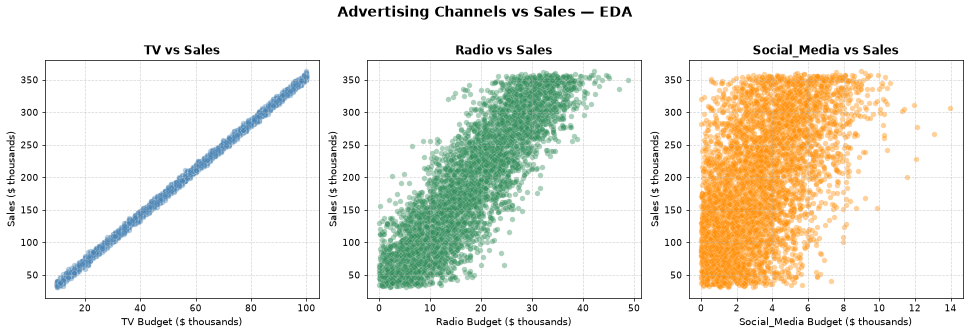

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

channels = ['TV', 'Radio', 'Social_Media']
colors = ['steelblue', 'seagreen', 'darkorange']

for i, (channel, color) in enumerate(zip(channels, colors)):
    axes[i].scatter(df_clean[channel], df_clean['Sales'],
                    color=color, alpha=0.4, edgecolors='white', linewidth=0.3)
    axes[i].set_title(f'{channel} vs Sales', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(f'{channel} Budget ($ thousands)', fontsize=11)
    axes[i].set_ylabel('Sales ($ thousands)', fontsize=11)
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Advertising Channels vs Sales — EDA',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation of each channel with Sales
corr = df_clean[['TV', 'Radio', 'Social_Media', 'Sales']].corr()

print("=== Correlation with Sales ===")
print(corr['Sales'].drop('Sales').sort_values(ascending=False))

=== Correlation with Sales ===
TV              0.999497
Radio           0.868638
Social_Media    0.527446
Name: Sales, dtype: float64


## EDA – Variable Selection & Visualization Analysis

### Correlation with Sales
| Channel      | Correlation |
|--------------|-------------|
| TV           | 0.9995      |
| Radio        | 0.8686      |
| Social Media | 0.5274      |

### Observations from Scatter Plots

1. **TV vs Sales** — Extremely strong positive linear relationship.
   Data points form an almost perfect straight line, indicating TV
   budget is a near-perfect predictor of sales.

2. **Radio vs Sales** — Moderate to strong positive relationship.
   Points show an upward trend but with more spread around the line
   compared to TV.

3. **Social Media vs Sales** — Weak positive relationship.
   Data points are widely scattered with no clear linear pattern,
   suggesting Social Media spend has little reliable impact on sales.

### Variable Selection
TV is selected as the independent variable (X) for the regression
model. With a correlation of 0.9995 with Sales, it is by far the
strongest predictor among the three channels.

In [ ]:
# Define X and y
X = df_clean['TV']
y = df_clean['Sales']

# Add constant (intercept) — required by statsmodels
X_ols = sm.add_constant(X)

# Fit OLS model
model_ols = sm.OLS(y, X_ols).fit()

# Display full summary
print(model_ols.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sun, 14 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:09:03   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## OLS Regression Results – Interpretation

### Model Equation
Sales = 3.5615 × TV + (-0.1325)
Sales ≈ 3.5615 × TV (intercept is negligible)

### Coefficients
| Term        | Coefficient | p-value | Interpretation                          |
|-------------|-------------|---------|------------------------------------------|
| Intercept   | -0.1325     | 0.188   | Not statistically significant (p > 0.05)|
| TV          |  3.5615     | 0.000   | Statistically significant (p < 0.05)    |

### Key Metrics

1. **R-squared: 0.999**
   99.9% of the variation in Sales is explained by TV advertising
   budget alone. This is an exceptionally strong model fit.

2. **Slope (TV coefficient): 3.5615**
   For every $1,000 increase in TV advertising budget, sales increase
   by approximately $3,561.50. This represents a very strong ROI.

3. **Intercept: -0.1325 (p = 0.188)**
   The intercept is not statistically significant since p > 0.05.
   This means when TV budget is zero, predicted sales are essentially
   zero, which makes practical sense.

4. **F-statistic: 4,517,000 (p = 0.00)**
   The overall model is highly statistically significant. TV budget
   is a valid and powerful predictor of sales.

5. **Durbin-Watson: 1.998**
   Value close to 2.0 indicates no autocorrelation in the residuals, a good sign for model validity.

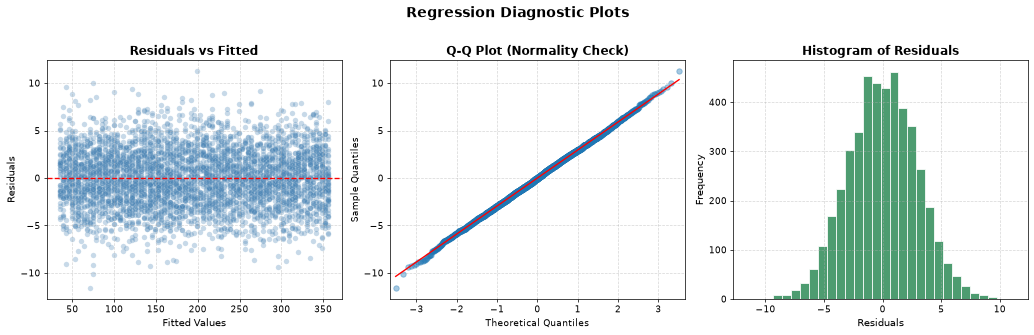

In [ ]:
# Get fitted values and residuals
fitted = model_ols.fittedvalues
residuals = model_ols.resid

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Residuals vs Fitted (Linearity & Homoscedasticity)
axes[0].scatter(fitted, residuals, alpha=0.3, color='steelblue', edgecolors='white', linewidth=0.3)
axes[0].axhline(y=0, color='red', linewidth=1.5, linestyle='--')
axes[0].set_title('Residuals vs Fitted', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Fitted Values', fontsize=11)
axes[0].set_ylabel('Residuals', fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.5)

# 2. Q-Q Plot (Normality)
sm.qqplot(residuals, line='s', ax=axes[1], alpha=0.4)
axes[1].set_title('Q-Q Plot (Normality Check)', fontsize=13, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)

# 3. Histogram of Residuals (Normality)
axes[2].hist(residuals, bins=30, color='seagreen', edgecolor='white', alpha=0.85)
axes[2].set_title('Histogram of Residuals', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Residuals', fontsize=11)
axes[2].set_ylabel('Frequency', fontsize=11)
axes[2].grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Regression Diagnostic Plots', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Regression Diagnostic Plots – Interpretation

### 1. Residuals vs Fitted (Linearity & Homoscedasticity)
The residuals are randomly and symmetrically scattered around the
horizontal zero line across all fitted values. There is no visible
pattern or funnel shape, confirming that:
- The linearity assumption is satisfied
- The homoscedasticity assumption is satisfied (constant variance)

### 2. Q-Q Plot (Normality of Residuals)
The sample quantiles follow the theoretical quantiles almost
perfectly along the red diagonal line. This confirms that the
residuals are approximately normally distributed, satisfying the
normality assumption of OLS regression.

### 3. Histogram of Residuals (Normality)
The residual distribution is approximately symmetric and bell-shaped,
centered near zero with no extreme skew. This further supports the
normality assumption required for valid OLS inference.

### Overall Conclusion
All three key OLS assumptions are satisfied:
✓ Linearity: confirmed by Residuals vs Fitted
✓ Normality: confirmed by Q-Q Plot and Histogram of Residuals
✓ Homoscedasticity: confirmed by Residuals vs Fitted
The model is statistically valid and reliable for prediction.


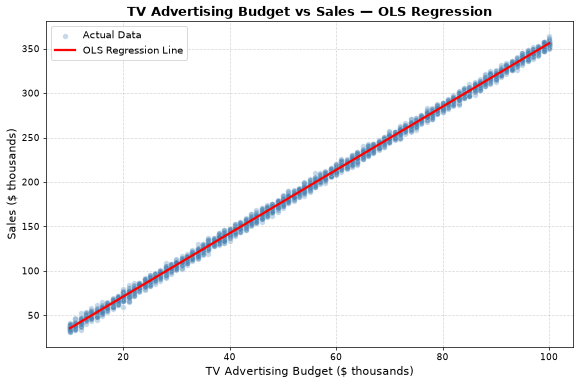

In [ ]:
# Regression line visualization (TV vs Sales with OLS fit)
x_line = np.linspace(df_clean['TV'].min(), df_clean['TV'].max(), 100)
y_line = model_ols.params['const'] + model_ols.params['TV'] * x_line

plt.figure(figsize=(9, 6))
plt.scatter(df_clean['TV'], df_clean['Sales'], color='steelblue',
            alpha=0.3, edgecolors='white', linewidth=0.3, label='Actual Data')
plt.plot(x_line, y_line, color='red', linewidth=2.5, label='OLS Regression Line')

plt.title('TV Advertising Budget vs Sales — OLS Regression',
          fontsize=14, fontweight='bold')
plt.xlabel('TV Advertising Budget ($ thousands)', fontsize=12)
plt.ylabel('Sales ($ thousands)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## Final Report – Marketing ROI Analysis & Recommendations

### Project Summary
This project applied Simple Linear Regression (OLS) to analyze the
relationship between three advertising channels; TV, Radio, and
Social Media, and product sales, using a dataset of 4,546 cleaned
observations.

### Key Findings

**Variable Selection**
Correlation analysis identified TV as the strongest predictor of
sales (r = 0.9995), followed by Radio (r = 0.8686) and Social Media
(r = 0.5274). TV was selected as the independent variable for the
final OLS model.

**Model Performance**
The OLS regression equation is:
    Sales = 3.5615 × TV − 0.1325

The model achieved an R-squared of 0.999, meaning 99.9% of the
variation in sales is explained by TV advertising spend alone.
The TV coefficient (3.5615) is statistically significant (p < 0.05),
while the intercept is not (p = 0.188), confirming that sales are
driven almost entirely by TV investment.

**Model Assumptions**
All three OLS assumptions were verified through diagnostic plots:
- Linearity ✓ ; residuals randomly scattered around zero
- Normality ✓ ; Q-Q plot shows near-perfect normal distribution
- Homoscedasticity ✓ ; constant variance across fitted values

### Business Recommendation
As marketing manager, I strongly recommend prioritising TV advertising
as the primary channel for budget allocation. Every $1,000 increase
in TV spend is predicted to generate approximately $3,561.50 in
additional sales, an exceptional return on investment.

Radio shows a moderate positive relationship and could serve as a
secondary channel to complement TV campaigns. Social Media, however,
shows the weakest and least consistent relationship with sales
(r = 0.5274) and should receive the lowest budget priority until
further analysis justifies increased investment.

The evidence from this model is clear: TV advertising delivers the
strongest, most reliable, and most statistically significant impact
on sales revenue.